In [1]:
from scipy.signal import convolve2d

In [3]:
import numpy as np 

kernel = np.ones((3,3))/9

In [4]:
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [5]:
gaussian_kernel = np.array([[1/16, 1/8, 1/16],
                            [1/8, 1/4, 1/8],
                            [1/16, 1/8, 1/16]])

In [8]:
from astroquery.skyview import SkyView
from scipy.signal import convolve2d
import numpy as np

img_list = SkyView.get_images(position="M31", survey="DSS")
hdu = img_list[0][0]
M31_Pixels = hdu.data

kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])

convolved_image = convolve2d(M31_Pixels, kernel, mode='same')

print("Convolution complete!")

Convolution complete!


In [9]:
M31_header = hdu.header
print(repr(M31_header))

SIMPLE  =                    T / Written by SkyView Mon May 04 21:52:16 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =              10.6847 / Reference longitude                            
CRVAL2  =              41.2688 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

In [11]:
gaussian_convolved_image = convolve2d(M31_Pixels, gaussian_kernel, mode='same')

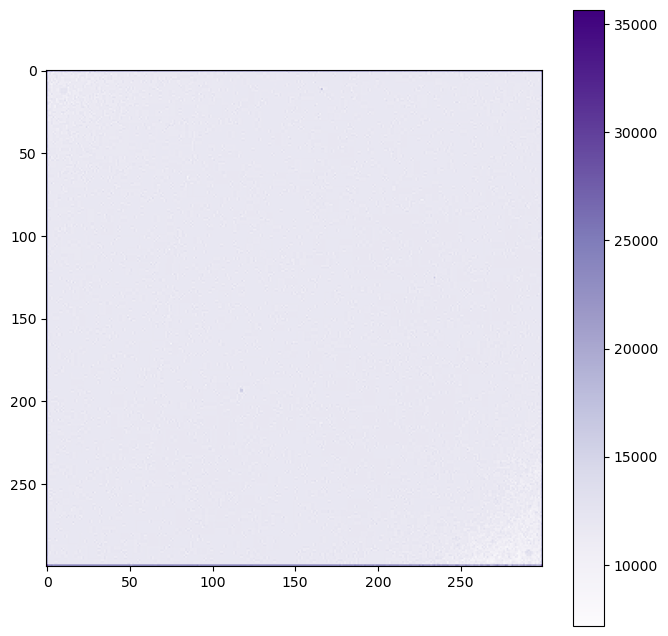

In [15]:
import matplotlib.pyplot as plt

def plot_pixels(data, title='Image', color='viridis'):
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap=color)
    plt.title(title, fontsize=15, color='white')
    plt.colorbar()
    plt.grid(False)
    plt.gca().set_facecolor('black') 
    plt.show()

plot_pixels(convolved_image, title='Normal Kernel Convolution', color='Purples')

In [18]:
grayscale_zint_array = hdu.data
convolved_grayscale = convolve2d(grayscale_zint_array, gaussian_kernel, mode='same')

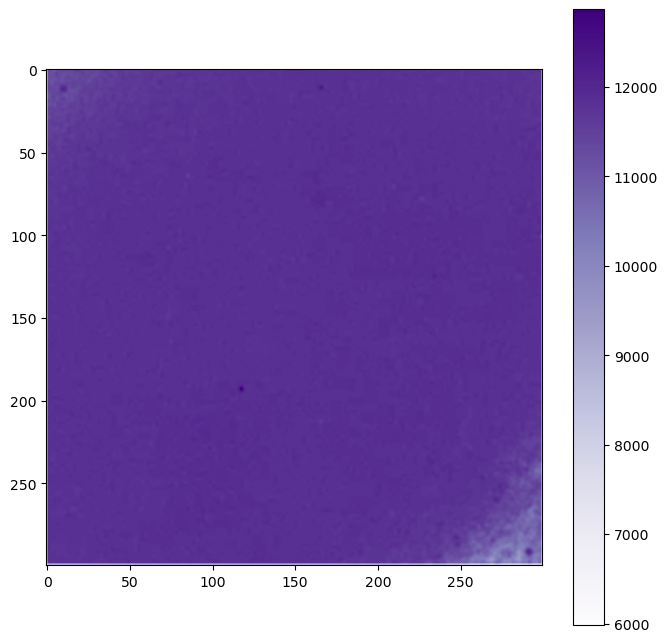

In [20]:
plot_pixels(convolved_grayscale, title='Gaussian Kernel on ZScaleInterval', color='Purples')

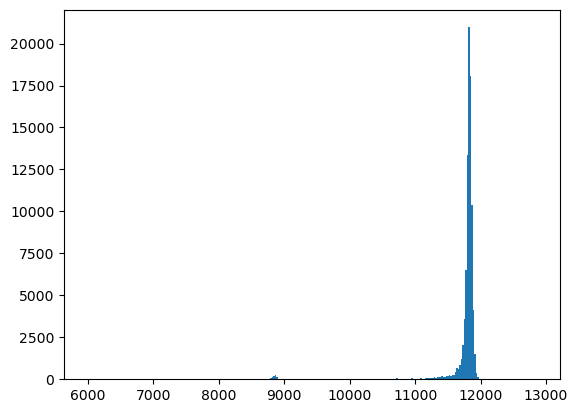

In [21]:
plt.hist(convolved_grayscale.flat, bins=300)
plt.show()

In [22]:
# ENHANCING THE LINEAR FEATURES

SPECTRAL_LIST = ["gray","jet","hot","prism","nipy_spectral"]

In [23]:
from skimage.filters import meijering, sato

In [24]:
meijering_output = meijering(convolved_grayscale)
sato_output = sato(convolved_grayscale)

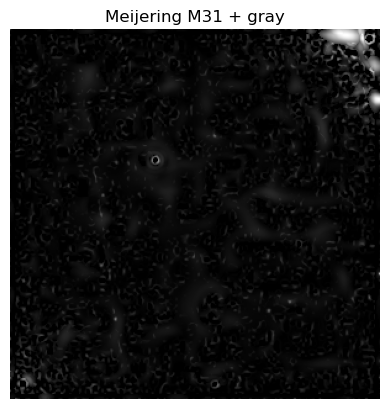

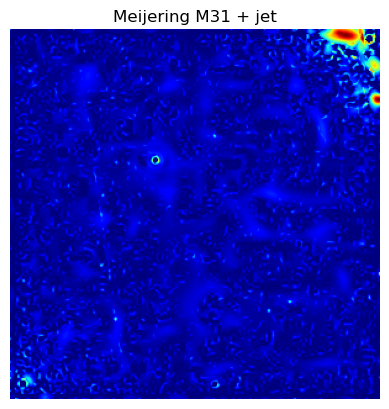

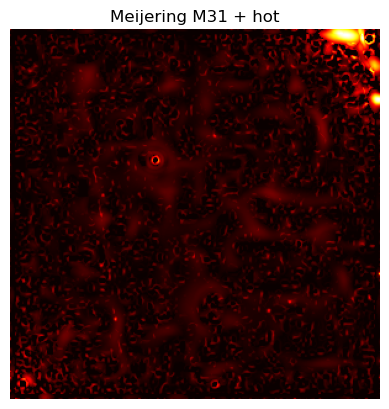

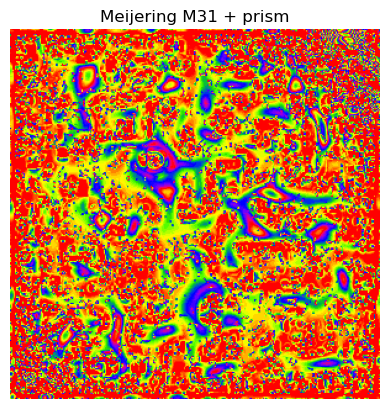

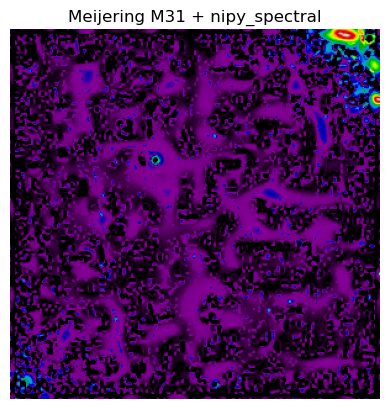

In [25]:
for colormap in SPECTRAL_LIST:
  plt.imshow(meijering_output, cmap=colormap, origin='lower')
  plt.title(f'Meijering M31 + {colormap}')
  plt.axis('off')
  plt.show()

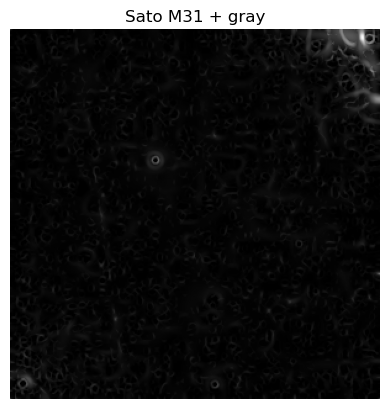

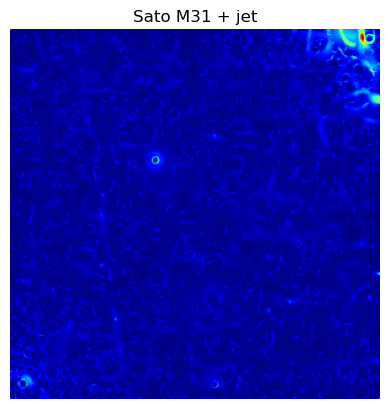

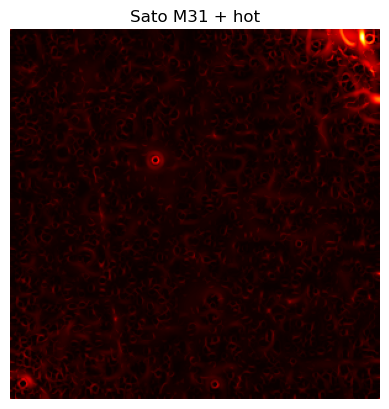

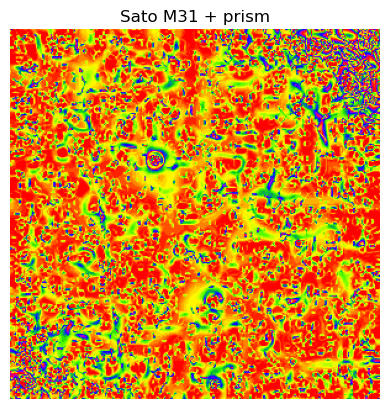

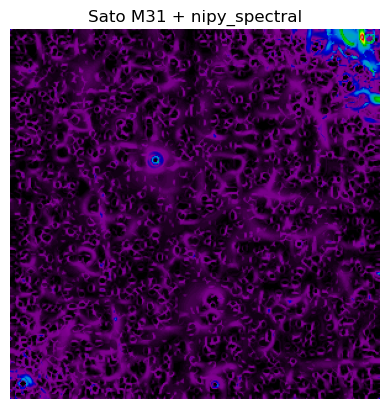

In [26]:
for colormap in SPECTRAL_LIST:
  plt.imshow(sato_output, cmap=colormap, origin='lower')
  plt.title(f'Sato M31 + {colormap}')
  plt.axis('off')
  plt.show()

In [ ]:
# FEATURE DETECTION AND EXTRACTION

In [27]:
from skimage.feature import corner_foerstner

In [28]:
feature_output = corner_foerstner(convolved_grayscale)

In [29]:
feature_output[1]

array([[0.72250931, 0.66878306, 0.25547584, ..., 0.243967  , 0.66120307,
        0.72075442],
       [0.66155263, 0.91249929, 0.56209433, ..., 0.54403747, 0.91051038,
        0.66507514],
       [0.24153895, 0.53851459, 0.98619358, ..., 0.98423963, 0.54910749,
        0.24795655],
       ...,
       [0.2452811 , 0.54504154, 0.98379607, ..., 0.99167826, 0.55352392,
        0.25160139],
       [0.66158044, 0.90901441, 0.54813516, ..., 0.55890616, 0.91987936,
        0.66848173],
       [0.71901319, 0.66190623, 0.24678454, ..., 0.25405221, 0.67563203,
        0.72808997]], shape=(300, 300))

In [30]:
type(feature_output)

tuple

In [31]:
len(feature_output)

2

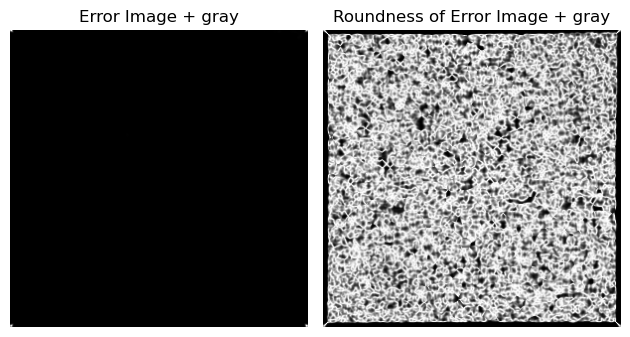

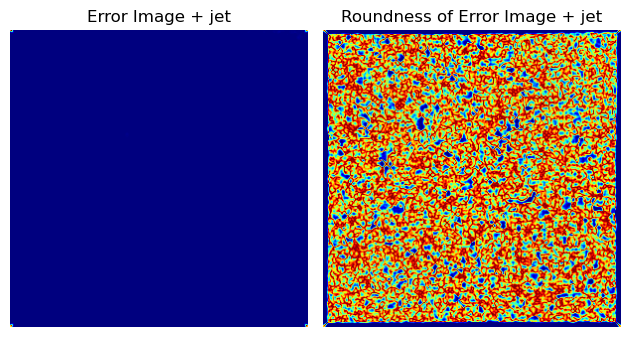

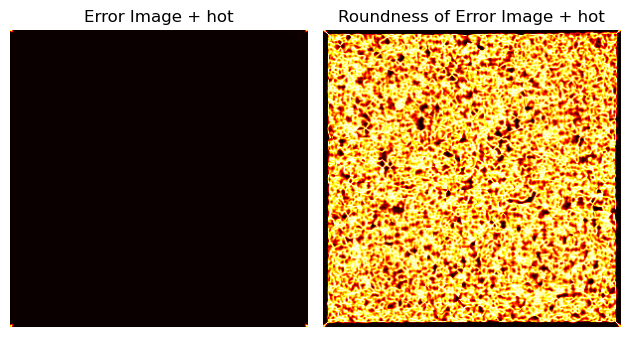

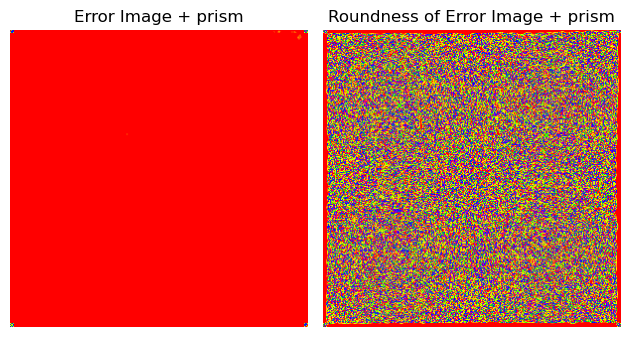

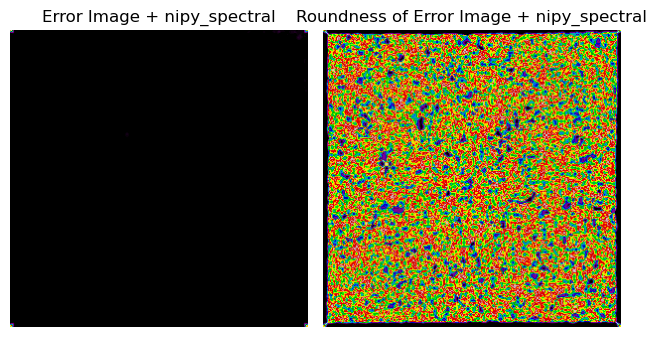

In [32]:
for colormap in SPECTRAL_LIST:
  plt.subplot(1, 2, 1)
  plt.imshow(feature_output[0], cmap=colormap, origin='lower')
  plt.title(f'Error Image + {colormap}')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(feature_output[1], cmap=colormap, origin='lower')
  plt.title(f'Roundness of Error Image + {colormap}')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
# MULTISCALE BASIC FEATURES (LOCAL FEATURES)

In [33]:
from skimage.feature import multiscale_basic_features

In [34]:
featured_image = multiscale_basic_features(convolved_grayscale)

In [35]:
type(featured_image)

numpy.ndarray

In [36]:
featured_image.shape

(300, 300, 24)

In [38]:
import cv2

P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24 = cv2.split(featured_image)

In [40]:
P1.shape

(300, 300)

In [41]:
P24.shape

(300, 300)

In [42]:
Pixels = [P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20,P21,P22,P23,P24]

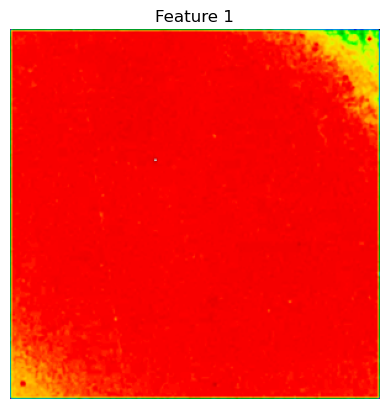

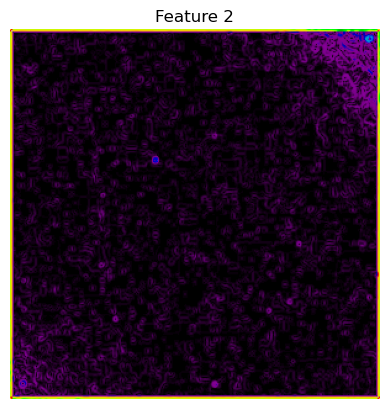

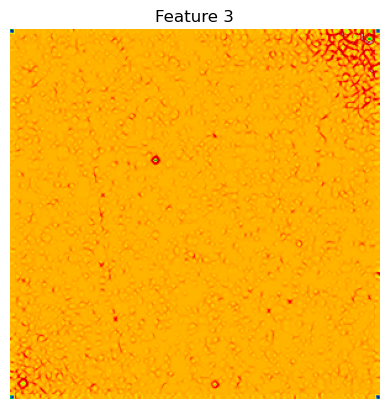

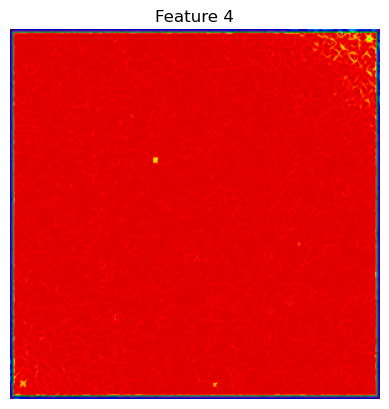

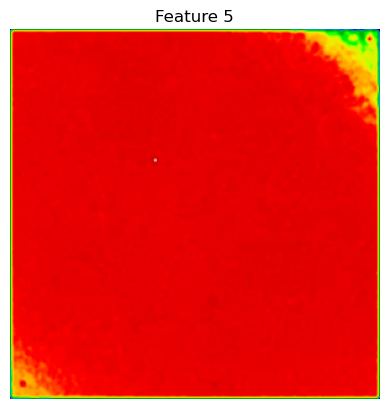

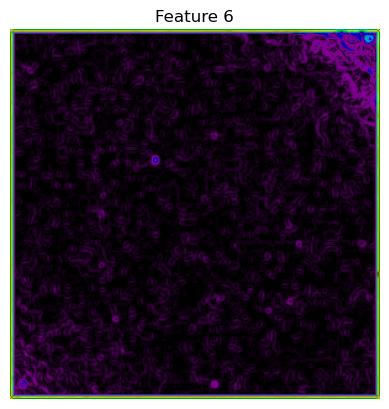

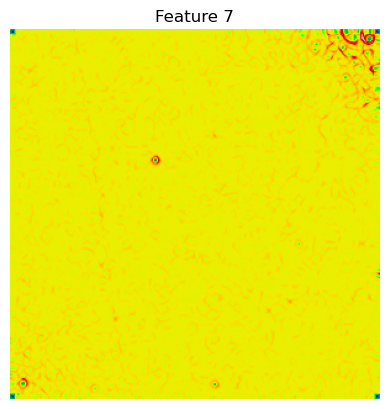

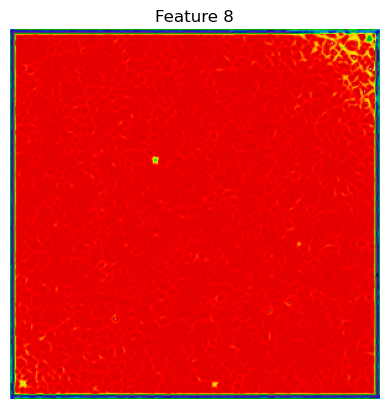

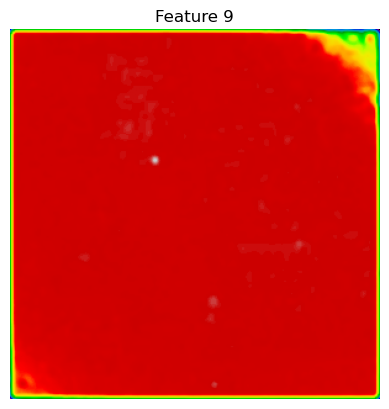

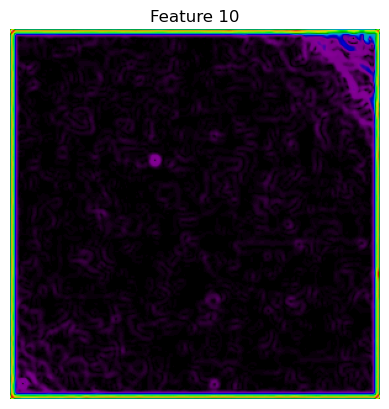

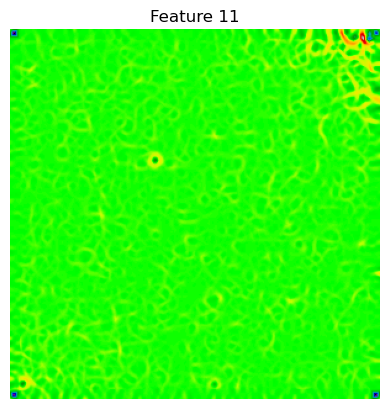

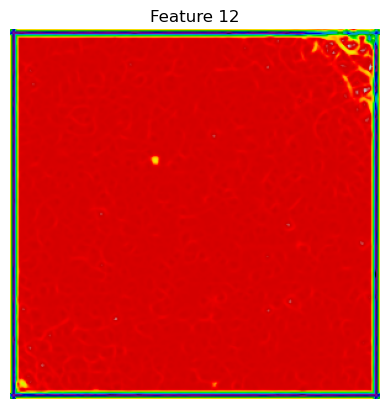

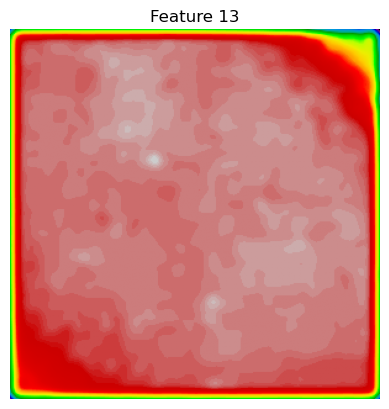

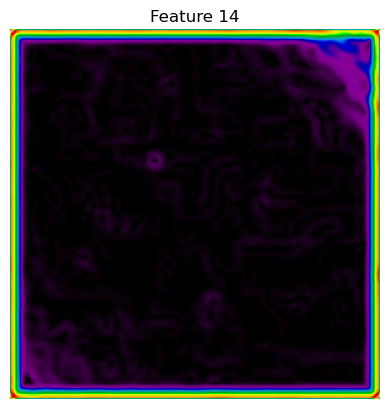

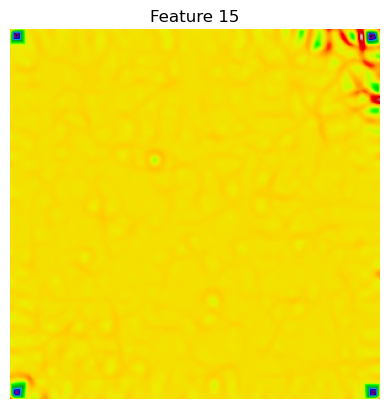

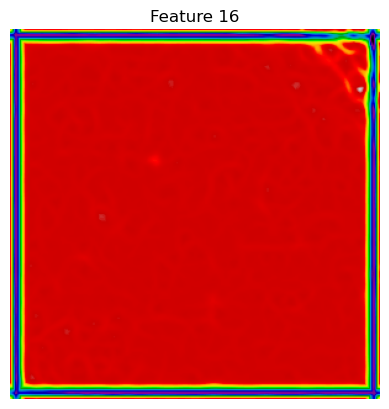

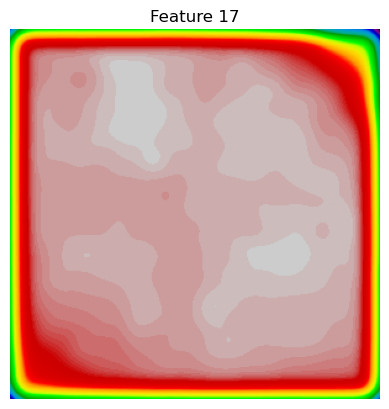

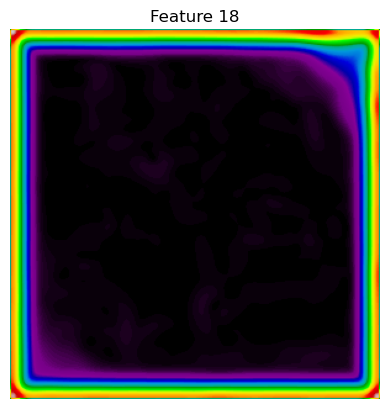

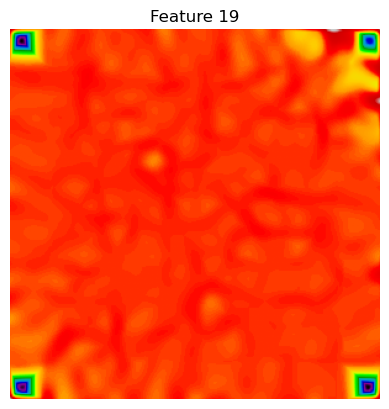

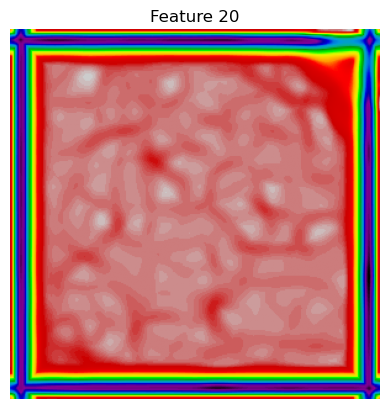

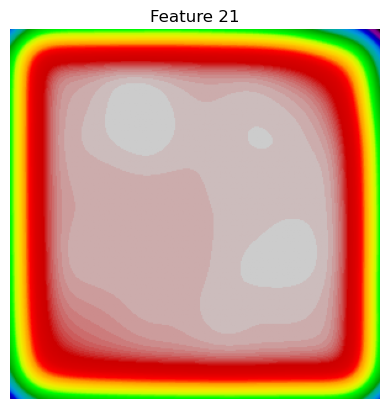

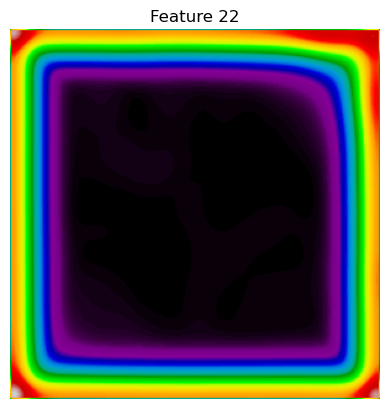

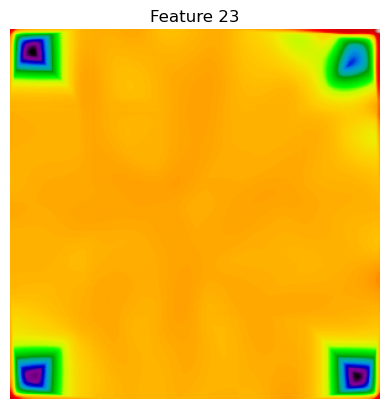

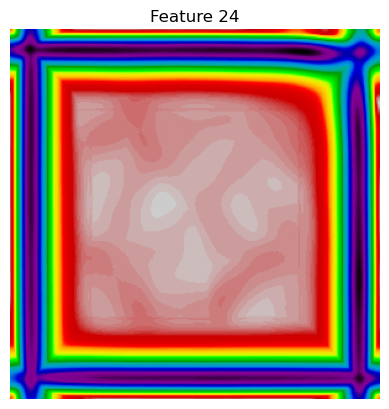

In [43]:
for i, feature in enumerate(Pixels):
  plt.imshow(feature, cmap='nipy_spectral', origin='lower')
  plt.title(f'Feature {i+1}')
  plt.axis('off')
  plt.show()